In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import librosa
import soundfile
import torch
import torchaudio
from torchaudio import transforms as T
import librosa
import soundfile

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

import sys
import os
sys.path.append('./dataset/cats_dogs_dataset')
import utils
import myutils

print(torch.cuda.is_available())

True


In [2]:
df = pd.read_csv(f'dataset/cats_dogs_dataset/train_test_split.csv', index_col=0)
df.head()

,test_cat,test_dog,train_cat,train_dog
0,cat_22.wav,dog_barking_97.wav,cat_99.wav,dog_barking_33.wav
1,cat_116.wav,dog_barking_0.wav,cat_54.wav,dog_barking_86.wav
2,cat_155.wav,dog_barking_93.wav,cat_34.wav,dog_barking_45.wav
3,cat_58.wav,dog_barking_10.wav,cat_132.wav,dog_barking_76.wav
4,cat_77.wav,dog_barking_26.wav,cat_124.wav,dog_barking_4.wav


In [3]:
df = df.dropna()
df.isna().sum()

test_cat     0
test_dog     0
train_cat    0
train_dog    0
dtype: int64

In [ ]:
audio_dir = 'dataset/cats_dogs_dataset/cats_dogs/'
extracted = {}

for columns in ['test_cat', 'test_dog', 'train_cat', 'train_dog']:

    rows = []

    for value in df[columns]:
        path = os.path.join(audio_dir, value)
        
        extracted_feat = myutils.feature_extraction(path)
        mean_mfcc = extracted_feat.pop('mean_mfcc')
        std_mfcc = extracted_feat.pop('std_mfcc')
        for i, v in enumerate(mean_mfcc):
            extracted_feat[f"mfcc_mean_{i+1}"] = v

        for i, v in enumerate(std_mfcc):
            extracted_feat[f"mfcc_std_{i+1}"] = v
        
        rows.append(extracted_feat)

    extracted[columns] = pd.DataFrame(rows)

In [5]:
for key, df in extracted.items():
    if "cat" in key:
        extracted[key] = pd.DataFrame(df)
        extracted[key]['target'] = 0
    elif "dog" in key:
        extracted[key] = pd.DataFrame(df)
        extracted[key]['target'] = 1

train_data = pd.concat([extracted['train_cat'], extracted['train_dog']], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
test_data = pd.concat([extracted['test_cat'], extracted['test_dog']], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

In [6]:
scaler = StandardScaler()

X_train = train_data.drop(columns=['target'])
y_train = train_data['target']

X_test = test_data.drop(columns=['target'])
y_test = test_data['target']

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
model_svm = SVC(kernel='linear')
model_svm.fit(X_train, y_train)

SVC(kernel='linear')

         EVALUATION RESULTS
Accuracy  : 0.8980
Precision : 0.9149
Recall    : 0.8776
F1 Score  : 0.8958

Classification Report:
              precision    recall  f1-score   support

         cat       0.88      0.92      0.90        49
         dog       0.91      0.88      0.90        49

    accuracy                           0.90        98
   macro avg       0.90      0.90      0.90        98
weighted avg       0.90      0.90      0.90        98



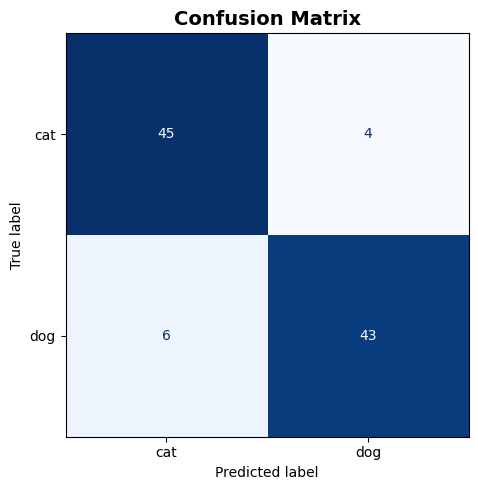

In [8]:
y_pred = model_svm.predict(X_test) 

print("=" * 40)
print("         EVALUATION RESULTS")
print("=" * 40)
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred, pos_label=1):.4f}")  # ✅ ganti 'dog' → 1
print(f"Recall    : {recall_score(y_test, y_pred, pos_label=1):.4f}")     # ✅
print(f"F1 Score  : {f1_score(y_test, y_pred, pos_label=1):.4f}")         # ✅
print("=" * 40)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['cat', 'dog'])) # ini tetap bisa pakai nama

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])                      # ✅ ganti jadi [0, 1]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['cat', 'dog'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()